In [1]:
from astropy.io import fits
import clevar
import sys

sys.path.insert(0, "/global/homes/l/lettieri/gcrcatalogs-new/gcr-catalogs")
sys.path.insert(0, "/global/homes/l/lettieri/gcr-catalogs")
sys.path.insert(0, "../match_by_proximity")

from clevar.match_metrics.recovery import ClCatalogFuncs as r_cf
from clevar.match_metrics.distances import ClCatalogFuncs as d_cf
from clevar.match_metrics.scaling import ClCatalogFuncs as s_cf
import clevar.match_metrics.scaling as scaling

import pandas as pd
from astropy.table import unique, Table
import astropy
from matplotlib import pyplot as plt
import numpy as np
from numcosmo_py import Ncm, Nc
from numcosmo_py.external.pyssc import pyssc as PySS
from numcosmo_py.helper import npa_to_seq
from numcosmo_py import sky_match
import time
from tqdm import tqdm
Ncm.cfg_init()
from time_model import PySLineModel, PySLineGauss

import GCRCatalogs
print('GCRCatalogs =', GCRCatalogs.__version__, '|' ,'GCR =', GCRCatalogs.GCR.__version__)
from GCR import GCRQuery
%load_ext autoreload
%autoreload 2

/global/homes/l/lettieri/.local/lib/python3.13/site-packages/hpgeom-0.0.0-py3.13-linux-x86_64.egg/hpgeom/_hpgeom.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.


GCRCatalogs = 1.10.2 | GCR = 0.9.2


In [2]:
min_halo_mass = 10**(12.5) #Msun
redshift_max = 1.2

#Cosmo DC2
cosmodc2 = GCRCatalogs.load_catalog('cosmoDC2_v1.1.4_image')

#Cosmo DC2 + RedMaPPer
catalog_dc2_redmapper = GCRCatalogs.load_catalog('cosmoDC2_v1.1.4_redmapper_v0.8.1')

redmapper_cosmology = catalog_dc2_redmapper.cosmology
sky_area = catalog_dc2_redmapper.sky_area

print("CosmoDC2 info:")
print(f"Version: {cosmodc2.get_catalog_info('version')}")
print(f"Sky area: {cosmodc2.get_catalog_info('sky_area')}")
print(f"Cosmology: {cosmodc2.get_catalog_info('cosmology')}")

quantities = catalog_dc2_redmapper.list_all_quantities()
cluster_quantities = [q for q in quantities if 'member' not in q]
member_quantities = [q for q in quantities if 'member' in q]

cluster_data = Table(catalog_dc2_redmapper.get_quantities(cluster_quantities)) # cDC2 + RM cluster data
member_data = Table(catalog_dc2_redmapper.get_quantities(member_quantities)) # cDC2 + RM member data
member_data.rename_column('cluster_id_member', 'cluster_id')

# # Restrictions on mass and redshift

quantities_wanted = ['redshift','halo_mass','halo_id','galaxy_id','ra','dec', 'is_central']
query = GCRCatalogs.GCRQuery('(halo_mass > ' + str(min_halo_mass) +') & (redshift < ' + str(redshift_max) +') & (is_central < ' + str(redshift_max) +') ')
truth_data = Table(cosmodc2.get_quantities(quantities_wanted, [query]))

table_halos = truth_data[truth_data['is_central'] == True]

CosmoDC2 info:
Version: 1.1.4
Sky area: 439.78987
Cosmology: {'H0': 71.0, 'Om0': 0.2648, 'Ob0': 0.0448, 'sigma8': 0.8, 'n_s': 0.963}


# ID match time test

/global/u2/l/lettieri/miniforge3/envs/numcosmo_developer/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/global/u2/l/lettieri/miniforge3/envs/numcosmo_developer/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/global/u2/l/lettieri/miniforge3/envs/numcosmo_developer/lib/python3.13/site-packages/numpy/_core/_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/global/u2/l/lettieri/miniforge3/envs/numcosmo_developer/lib/python3.13/site-packages/numpy/_core/_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/global/u2/l/lettieri/miniforge3/envs/numcosmo_developer/lib/python3.13/site-packages/numpy/_core/_methods.py:214: RuntimeWarning: inval

#----------------------------------------------------------------------------------
# Model fitting. Iterating using:
#  - solver:            NLOpt:ln-neldermead
#  - differentiation:   Numerical differentiation (forward)
#  Minimum found with precision: |df|/f =  0.00000e+00 and |dx| =  0.00000e+00
#  Elapsed time: 00 days, 00:00:00.0021790
#  iteration            [000000]
#  function evaluations [000001]
#  gradient evaluations [000000]
#  degrees of freedom   [000010]
#  m2lnL     =                    0 (          -nan )
#  Fit parameters:
#     0.9                    0.2                   
#----------------------------------------------------------------------------------
# Data used:
#   - time_model+PySLineGauss
#----------------------------------------------------------------------------------
# Model[23000]:
#   - NcPySLineModel : NcPySLineModel
#----------------------------------------------------------------------------------
# Model parameters
#   - alpha[00]:  0.9          

NameError: name 'k' is not defined

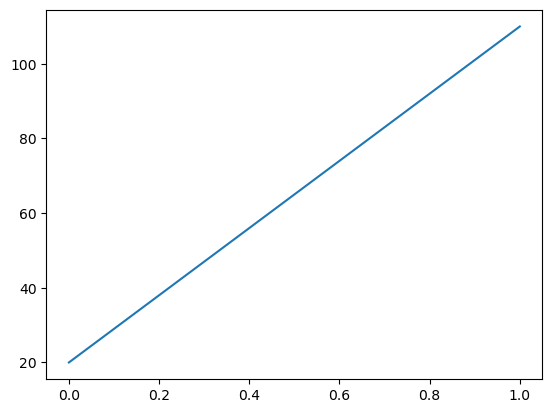

In [3]:
halo_coordinates = {"RA":"ra" , "DEC":"dec" , "z":"redshift"}
halo_ids  = {"ID": "halo_id", "MemberID": "galaxy_id"}

detections_coordinates =  {"RA":"ra" , "DEC":"dec" , "z":"redshift"}
detections_ids  = {"ID": "cluster_id", "MemberID": "id_member"}

min_mass = [12.5, 12.6, 12.7, 12.8, 12.9,  13, 13.3, 13.4, 13.5, 13.7, 13.8, 14]
pbar = tqdm(min_mass, desc="Processing Mass Thresholds", unit="mass")
mean_time_halo_m = []
mean_time_halo_b = []
mean_time_halo = []
std_time_halo_m  = []
std_time_halo_b  = []
std_time_halo = []
size_halo = []
for mass in pbar:
    # Update the progress bar suffix with the current mass value
    pbar.set_postfix({"Current Mass": f"{mass:.2e}"})
    
    reduced_halos = table_halos[table_halos['halo_mass'] >= mass]
    size_halo.append(len(reduced_halos['halo_mass']))

    halos_m = sky_match.SkyMatch(
    query_data= table_halos,
    query_coordinates=halo_coordinates,
    query_member_data=truth_data,
    query_ids = halo_ids, 
    match_data=cluster_data,
    match_coordinates=detections_coordinates,
    match_member_data=member_data,
    match_ids = detections_ids
    )

    time_match_m, time_match_b, time_match = [], [], []
    for i in range(5):
        start = time.perf_counter()
        # Match phase
        start_m = time.perf_counter()
        halos_matched = halos_m.match_ID()
        end_m = time.perf_counter()        
        time_match_m.append(end_m - start_m) 

        # Best selection phase
        start_b = time.perf_counter()
        best_halos = halos_matched.select_best()
        end_b = time.perf_counter()       
        time_match_b.append(end_b - start_b)

    

    time_match_m = np.array(time_match_m)
    time_match_b = np.array(time_match_b)
    time_match   = np.array(time_match)
    
    mean_time_halo_m.append(np.mean(time_match_m))
    std_time_halo_m.append(np.std(time_match_m))

    mean_time_halo_b.append(np.mean(time_match_b))
    std_time_halo_b.append(np.std(time_match_b))

    mean_time_halo.append(np.mean(time_match))
    std_time_halo.append(np.std(time_match))

mean_time_halo_m = np.array(mean_time_halo_m)
std_time_halo_m = np.array(std_time_halo_m)

mean_time_halo_b = np.array(mean_time_halo_b)
std_time_halo_b = np.array(std_time_halo_b)


mean_time_halo = np.array(mean_time_halo)
std_time_halo = np.array(std_time_halo)
size_halo = np.array(size_halo)

slm = PySLineModel()
slm.props.alpha = 0.9
slm.props.a = 0.2


mset = Ncm.MSet.empty_new()
mset.set(slm)
mset.param_set_all_ftype(Ncm.ParamType.FREE)
mset.prepare_fparam_map()

cov = Ncm.Matrix.new(len(mean_time_halo), len(mean_time_halo))
cov.set_zero()
cov.set_diag(Ncm.Vector.new_array(npa_to_seq(np.array(std_time_halo)/100)))

sld = PySLineGauss()
sld.set_size(len(mean_time_halo))
sld.set_init(True)
sld.use_norma(False)

sld.xv = Ncm.Vector.new_array(npa_to_seq(size_halo/1e6))
sld.set_cov(cov)
sld.peek_mean().set_array(npa_to_seq(mean_time_halo/100))


dset = Ncm.Dataset.new()
dset.append_data(sld)
lh = Ncm.Likelihood.new(dset)

fit = Ncm.Fit.factory(Ncm.FitType.NLOPT, "ln-neldermead", lh, mset, Ncm.FitGradType.NUMDIFF_FORWARD)
fit.run(Ncm.FitRunMsgs.FULL)
fit.log_info()
fit.obs_fisher()
fit.log_covar()

def bf_plot(x):
    return 100*(slm.props.alpha * x + slm.props.a)
x_v= np.linspace(0 , 1, 1000)
# Capture the line object
line, = plt.plot(x_v, bf_plot(x_v))

# Get the color from that line and apply it to errorbar
plt.errorbar(size_halo/1e6, mean_time_halo, yerr=std_time_halo, fmt='o', 
              color=line.get_color())

plt.legend()
plt.ylabel("Time(s)")
plt.xlabel(r"N objects ($10^6$)")
plt.savefig("plot_time_x_nobjects_id.pdf")
plt.show()

In [ ]:
def bf_plot(x):
    return 100*(slm.props.alpha * x + slm.props.a)
x_v= np.linspace(0 , 1, 1000)
# Capture the line object
line, = plt.plot(x_v, bf_plot(x_v))

# Get the color from that line and apply it to errorbar
plt.errorbar(size_halo/1e6, mean_time_halo, yerr=std_time_halo, fmt='o', 
              color=line.get_color())

plt.legend()
plt.ylabel("Time(s)")
plt.xlabel(r"N objects ($10^6$)")
plt.savefig("plot_time_x_nobjects_id.pdf")
plt.show()

In [ ]:
plt.errorbar(size_halo, mean_time_halo_m, yerr=std_time_halo_m, fmt='o',label="multiple matching")
#plt.xscale("log")
plt.legend()
plt.show()
plt.errorbar(size_halo, mean_time_halo_b, yerr=std_time_halo_b, fmt='o',label="best matching")
plt.xscale("log")
plt.legend()
plt.show()
plt.errorbar(size_halo, mean_time_halo_c, yerr=std_time_halo_c, fmt='o',label="cross matching")
plt.legend()
plt.xscale("log")
plt.show()
plt.errorbar(size_halo, mean_time_halo, yerr=std_time_halo, fmt='o',label="full matching")
plt.legend()
#plt.xscale("log")
plt.show()
# O(n), teste de extremos muita incompletude e pureza

mean_time_halo = np.array(mean_time_halo)
std_time_halo = np.array(std_time_halo)
print("mean")
print(mean_time_halo)
print("var")
print(std_time_halo)